In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

fraud = pd.read_csv(
    '../data/processed/fraud_clean.csv'
)

ip_country = pd.read_csv(
    '../data/raw/IpAddress_to_Country.csv'
)

In [3]:
fraud['signup_time'] = pd.to_datetime(
    fraud['signup_time']
)

fraud['purchase_time'] = pd.to_datetime(
    fraud['purchase_time']
)

In [4]:
fraud['ip_address'] = fraud[
    'ip_address'
].astype(int)

In [5]:
ip_country[
'lower_bound_ip_address'
] = ip_country[
'lower_bound_ip_address'
].astype(int)

In [6]:
ip_country[
'upper_bound_ip_address'
] = ip_country[
'upper_bound_ip_address'
].astype(int)

In [7]:
fraud = fraud.sort_values(
    'ip_address'
)

ip_country = ip_country.sort_values(
    'lower_bound_ip_address'
)

In [8]:
fraud_geo = pd.merge_asof(
    fraud,
    ip_country,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [9]:
fraud_geo = fraud_geo[
fraud_geo['ip_address']
<= fraud_geo['upper_bound_ip_address']
]

In [10]:
country_fraud = fraud_geo.groupby(
    'country'
)['class'].mean().sort_values(
    ascending=False
)

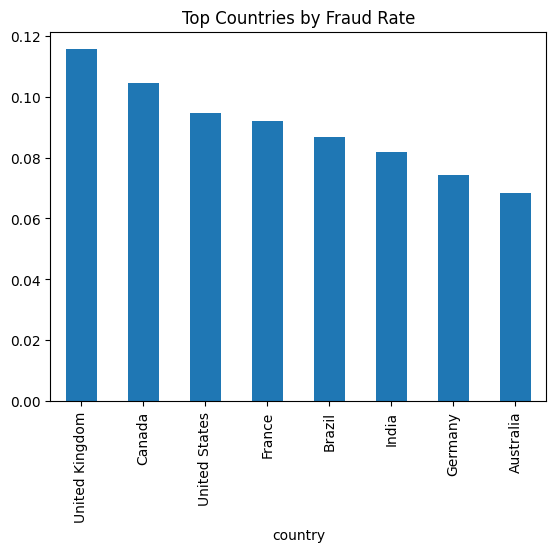

In [11]:
country_fraud.head(10).plot(
    kind='bar'
)

plt.title(
'Top Countries by Fraud Rate'
)

plt.show()

In [12]:
fraud_geo[
'time_since_signup'
] = (
fraud_geo['purchase_time']
-
fraud_geo['signup_time']
).dt.total_seconds()

In [13]:
fraud_geo[
'hour_of_day'
] = fraud_geo[
'purchase_time'
].dt.hour

In [14]:
fraud_geo[
'day_of_week'
] = fraud_geo[
'purchase_time'
].dt.dayofweek

In [15]:
fraud_geo[
'user_tx_count'
] = (
fraud_geo.groupby(
'user_id'
)['user_id']
.transform('count')
)

In [16]:
fraud_geo[
'device_tx_count'
] = (
fraud_geo.groupby(
'device_id'
)['device_id']
.transform('count')
)

In [17]:
fraud_geo = fraud_geo.sort_values(
['user_id','purchase_time']
)

In [18]:
fraud_geo[
'prev_purchase'
] = (
fraud_geo.groupby(
'user_id'
)['purchase_time']
.shift(1)
)

In [19]:
fraud_geo[
'transaction_velocity'
] = (
fraud_geo['purchase_time']
-
fraud_geo['prev_purchase']
).dt.total_seconds()

In [20]:
fraud_geo[
'transaction_velocity'
].fillna(
fraud_geo[
'transaction_velocity'
].median(),
inplace=True
)

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [21]:
fraud_model = fraud_geo.drop(
    columns=[
        'signup_time',
        'purchase_time',
        'prev_purchase'
    ],
    errors='ignore'
)

In [22]:
fraud_model.head()

,user_id,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country,time_since_signup,hour_of_day,day_of_week,user_tx_count,device_tx_count,transaction_velocity
88685,8,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,356056736,0,350000000.0,399999999.0,Brazil,6667201.0,11,3,1,1,NaN
91524,64,15,QOOCCLKFDGFHY,SEO,Safari,M,19,433200491,0,400000000.0,449999999.0,India,4518193.0,18,3,1,1,NaN
87665,148,46,QQYHWAHYABKHI,Direct,Safari,M,26,328390493,0,300000000.0,349999999.0,France,4971984.0,0,3,1,1,NaN
86485,153,18,SCWDWHYNNNULH,Ads,Chrome,M,35,293136018,1,250000000.0,299999999.0,Germany,1701001.0,7,5,1,1,NaN
86493,166,17,NYMGAADTQGCOH,Ads,FireFox,M,31,293445406,0,250000000.0,299999999.0,Germany,5847711.0,0,5,1,1,NaN


In [23]:
cat_cols = [
    'source',
    'browser',
    'sex',
    'country'
]

In [24]:
fraud_encoded = pd.get_dummies(
    fraud_model,
    columns=cat_cols,
    drop_first=True
)

In [25]:
fraud_encoded.shape

(14542, 28)

In [26]:
fraud_encoded.columns

Index(['user_id', 'purchase_value', 'device_id', 'age', 'ip_address', 'class',
       'lower_bound_ip_address', 'upper_bound_ip_address', 'time_since_signup',
       'hour_of_day', 'day_of_week', 'user_tx_count', 'device_tx_count',
       'transaction_velocity', 'source_Direct', 'source_SEO',
       'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari',
       'sex_M', 'country_Brazil', 'country_Canada', 'country_France',
       'country_Germany', 'country_India', 'country_United Kingdom',
       'country_United States'],
      dtype='object')

In [27]:
num_cols = [
    'purchase_value',
    'age',
    'time_since_signup',
    'user_tx_count',
    'device_tx_count',
    'transaction_velocity'
]

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

fraud_encoded[num_cols] = scaler.fit_transform(
    fraud_encoded[num_cols]
)

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [30]:
fraud_encoded[num_cols].head()

,purchase_value,age,time_since_signup,user_tx_count,device_tx_count,transaction_velocity
88685,0.552652,-0.944673,0.560633,0.0,-0.227204,NaN
91524,-1.198363,-1.643258,-0.130629,0.0,-0.227204,NaN
87665,0.497933,-0.828243,0.015340,0.0,-0.227204,NaN
86485,-1.034206,0.219635,-1.036824,0.0,-0.227204,NaN
86493,-1.088925,-0.246088,0.297031,0.0,-0.227204,NaN


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
fraud_encoded = pd.get_dummies(
    fraud_model,
    columns=cat_cols,
    drop_first=True
)

In [33]:
X = fraud_encoded.drop(
    'class',
    axis=1
)

y = fraud_encoded['class']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
print(y_train.value_counts())

class
0    10587
1     1046
Name: count, dtype: int64


In [36]:
print(
    y_train.value_counts(normalize=True)*100
)

class
0    91.008338
1     8.991662
Name: proportion, dtype: float64


In [37]:
from imblearn.over_sampling import SMOTE

In [38]:
print(fraud_encoded.shape)

(14542, 28)


In [39]:
y = fraud_encoded['class']

X = fraud_encoded.drop(
    'class',
    axis=1
)

print(X.shape)
print(y.shape)

(14542, 27)
(14542,)


In [40]:
X = fraud_encoded.drop(
    ['class', 'user_id', 'device_id'],
    axis=1
)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11633 entries, 89410 to 80101
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   purchase_value          11633 non-null  int64  
 1   age                     11633 non-null  int64  
 2   ip_address              11633 non-null  int32  
 3   lower_bound_ip_address  11633 non-null  float64
 4   upper_bound_ip_address  11633 non-null  float64
 5   time_since_signup       11633 non-null  float64
 6   hour_of_day             11633 non-null  int32  
 7   day_of_week             11633 non-null  int32  
 8   user_tx_count           11633 non-null  int64  
 9   device_tx_count         11633 non-null  int64  
 10  transaction_velocity    0 non-null      float64
 11  source_Direct           11633 non-null  bool   
 12  source_SEO              11633 non-null  bool   
 13  browser_FireFox         11633 non-null  bool   
 14  browser_IE              11633 non-null 

In [43]:
X_train.select_dtypes(include='object').head()

""
89410
84008
83147
80881
84637


In [44]:
X_train.isnull().sum().sort_values(ascending=False).head(10)

transaction_velocity      11633
purchase_value                0
browser_FireFox               0
country_United Kingdom        0
country_India                 0
country_Germany               0
country_France                0
country_Canada                0
country_Brazil                0
sex_M                         0
dtype: int64

In [45]:
X_train = X_train.drop(columns=['transaction_velocity'])
X_test = X_test.drop(columns=['transaction_velocity'])

In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [47]:
print(
    y_train_smote.value_counts()
)

class
0    10587
1    10587
Name: count, dtype: int64


<Axes: xlabel='class', ylabel='count'>

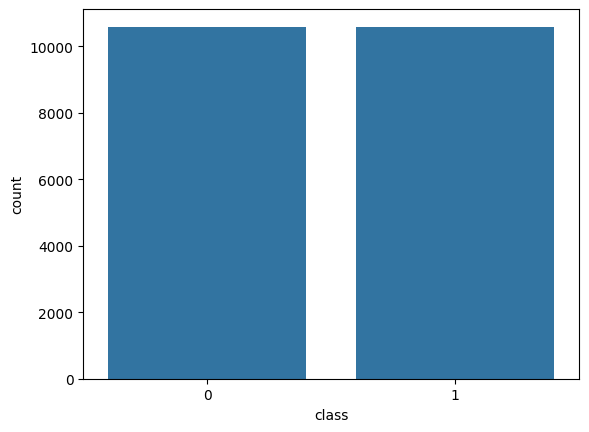

In [48]:
sns.countplot(
    x=y_train_smote
)

In [49]:
fraud_encoded.to_csv(
    '../data/processed/fraud_processed.csv',
    index=False
)